# Model aggregation & lifetime sanity checks (`test_models`)

Diagnostic notebook based on [`AAOD_error_attribution.ipynb`](AAOD_error_attribution.ipynb).

**Goals**
- Sanity-check per-model regional aggregation and BC+OA lifetime used in the AAOD error-attribution workflow.
- Inspect any mapped variable (default AAOD) for one model or all models.
- Compare regional model fields to **homogenized POLDER** and model precipitation to **GPCP**.

**Inputs (cell below)**
- `SAVE_FIGURE` — write PNGs under `notebooks/test_models_figs/`.
- `MODEL_NAME` — one AeroCom model id, or `None` if looping.
- `LOOP_ALL_MODELS` — if `True`, run the check for every loaded model (**requires** `SAVE_FIGURE=True`).
- `MAP_VAR` — field to map / ensemble-plot (`abs550aer`, `SSA`, `MAC`, `od550aer`, …).
- `ENSEMBLE_REGION` — region for the ensemble bar/scatter vs POLDER (default `africa`).
- `LIFETIME_METHOD` — `'load_emi'` → global τ = ⟨load_BC_OA⟩ / ⟨emi_BC_OA⟩, or `'load_dep'` → ⟨load_BC_OA⟩ / ⟨dep_BC_OA⟩ (spatial means, not per-gridcell).


In [ ]:
# =============================================================================
# Configuration
# =============================================================================
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore', category=RuntimeWarning)

project_root = Path('/scistor/guest/gbb083/AeroCom')
sys.path.insert(0, str(project_root / 'py'))
import cameo_toolbox as ct
import aerocom_data

# --- User inputs ---
SAVE_FIGURE = False
FIG_DIR = project_root / 'Figures' / 'model_validation'
FIG_DIR.mkdir(parents=True, exist_ok=True)
LOOP_ALL_MODELS = False          # if True, SAVE_FIGURE must be True

MAP_VAR = 'abs550aer'             # map + ensemble variable (AAOD default)
# Common choices: 'abs550aer', 'SSA', 'MAC', 'od550aer', 'lifetime_BC_OA', 'precip'
ENSEMBLE_REGION = 'africa'        # region for ensemble vs POLDER comparison
LIFETIME_METHOD = 'load_emi'      # 'load_emi' | 'load_dep'
# Global lifetime uses spatial means (not gridcell-wise mean of load/sink):
#   load_emi:  tau = mean(load_BC_OA) / (mean(emi_BC_OA) * 86400)   [days]
#   load_dep:  tau = mean(load_BC_OA) / (mean(dep_BC_OA) * 86400)   [days]

# Optional: restrict global lifetime / map season (None = full 2010)
GLOBAL_TIME_SLICE = ('2010-01-01', '2010-12-31')
MAP_TIME_INDEX = 0                # which monthly step to show on the map (after time_slice)

VARIABLES = [
    'abs550aer', 'od550aer', 'od440aer', 'od870aer', 'od865aer',
    'loadbc', 'loadoa', 'emibc', 'emioa',
    'depbc', 'depoa',
    'precip',
]




In [13]:

EXCLUDE_MODELS = [
    'GEOS-i33p2-met2010_AP3-CTRL-2010',
    'GISS-ModelE2p1p1-OMA_AP3-CTRL-2010',
    'GISS-ModelE2p1p1-MATRIX_AP3-CTRL-2010',
    # 'GISS-ModelE2p1p1-MATRIX_AP3-CTRL',
    # 'NorESM2-met2010_AP3-CTRL-v3',
]
print('Loading monthly NetCDF from AP3_processed_monthly...')
raw_data = aerocom_data.load_monthly_data_from_netcdf(
    output_base_dir=str(project_root / 'Data' / 'AP3_processed_monthly'),
    variables=VARIABLES,
)
models = sorted(m for m in raw_data if m not in EXCLUDE_MODELS)
print(f'Loaded {len(models)} models (excluded {len(EXCLUDE_MODELS)} listed)')
models


Loading monthly NetCDF from AP3_processed_monthly...
Loaded 264 NetCDF files for 30 models from /scistor/guest/gbb083/AeroCom/Data/AP3_processed_monthly
Loaded 28 models (excluded 3 listed)


['CAM5-ATRAS_AP3-CTRL',
 'CAM5.3-Oslo_AP3-CTRL2016-PD',
 'CAM5_CTRL2016',
 'EC-Earth3-AerChem-met2010_AP3-CTRL2019',
 'ECHAM6-HAM2_AP3-CTRL2016-PD',
 'ECHAM6-SALSA_CTRL2016-PD',
 'ECHAM6.3-HAM2.3-met2010_AP3-CTRL',
 'ECHAM6.3-SALSA2.0-met2010_AP3-CTRL',
 'ECMWF-IFS-CY42R1-CAMS-RA-CTRL_AP3-CTRL2016-PD',
 'ECMWF-IFS-CY45R1-CAMS-CTRL-met2010_AP3-CTRL',
 'ECMWF-IFS-CY46R1-CAMS-CTRL-met2010_AP3-CTRL',
 'ETHZ-ECHAM6-HAM2_CTRL2015',
 'GEOS-Chem-v11-01_AP3-CTRL2016-PD',
 'GEOS-i33p2-met2010_AP3-CTRL',
 'GFDL-AM4-met2010_AP3-CTRL',
 'GISS-ModelE2p1p1-MATRIX_AP3-CTRL',
 'GISS-ModelE2p1p1-OMA_AP3-CTRL',
 'HadGEM3-GA7.1_AP3-CTRL2016-PD',
 'IMPACT_CTRL2016',
 'INCA_AP3-CTRL',
 'MIROC-SPRINTARS_AP3-CTRL',
 'NorESM2-met2010_AP3-CTRL',
 'NorESM2-met2010_AP3-CTRL-v3',
 'OsloCTM3v1.01-met2010_AP3-CTRL',
 'OsloCTM3v1.02-met2010_AP3-CTRL',
 'SPRINTARS-T213_AP3-CTRL2016-PD',
 'TM5-met2010_AP3-CTRL2019',
 'TM5_AP3-CTRL2016']

In [ ]:
# Choose models
MODEL_NAME = 'TM5-met2010_AP3-CTRL2019'   # e.g. 'CAM5_CTRL2016'; set None if LOOP_ALL_MODELS
# Same study regions as AAOD_error_attribution (pass lon/lat explicitly into masks)
REGIONS = {
    'africa': {
        'surface_type': 'land',
        'lon_range': (15, 37), 'lat_range': (-15, 0),
        'time_slice': ('2010-06-01', '2010-09-30'), 'edge_weighted': False,
    },
    'amazon': {
        'surface_type': 'land',
        'lon_range': (287, 317), 'lat_range': (-17, -3),
        'time_slice': ('2010-07-01', '2010-10-31'), 'edge_weighted': False,
    },
    'outflow_af': {
        'surface_type': 'ocean',
        'lon_range': (350, 8), 'lat_range': (-15, 3),
        'time_slice': ('2010-06-01', '2010-09-30'), 'edge_weighted': True,
    },
    'boreal_na_west': {
        'surface_type': 'land',
        'lon_range': (242, 258), 'lat_range': (52, 63),
        'time_slice': ('2010-06-01', '2010-08-31'), 'edge_weighted': False,
    },
    'indonesia_peatland': {
        'surface_type': 'land',
        'lon_range': (98, 118), 'lat_range': (-5, 5),
        'time_slice': ('2010-08-01', '2010-11-15'), 'edge_weighted': False,
    },
}
SOURCE_REGIONS = ['africa', 'amazon', 'boreal_na_west', 'indonesia_peatland']

POLDER_HOMOGENIZE = True 

# Validate loop / save policy
if LOOP_ALL_MODELS and not SAVE_FIGURE:
    raise ValueError('LOOP_ALL_MODELS=True requires SAVE_FIGURE=True')
if not LOOP_ALL_MODELS and not MODEL_NAME:
    raise ValueError('Set MODEL_NAME or enable LOOP_ALL_MODELS')

print('--- test_models config ---')
print(f'  SAVE_FIGURE       = {SAVE_FIGURE}')
print(f'  MODEL_NAME        = {MODEL_NAME}')
print(f'  LOOP_ALL_MODELS  = {LOOP_ALL_MODELS}')
print(f'  MAP_VAR           = {MAP_VAR}')
print(f'  ENSEMBLE_REGION   = {ENSEMBLE_REGION}')
print(f'  LIFETIME_METHOD   = {LIFETIME_METHOD}')

--- test_models config ---
  SAVE_FIGURE       = False
  MODEL_NAME        = TM5-met2010_AP3-CTRL2019
  LOOP_ALL_MODELS  = False
  MAP_VAR           = abs550aer
  ENSEMBLE_REGION   = africa
  LIFETIME_METHOD   = load_emi


## Load monthly AeroCom data


In [15]:

if not LOOP_ALL_MODELS:
    if MODEL_NAME not in models:
        # fuzzy help
        hits = [m for m in models if MODEL_NAME and MODEL_NAME.lower() in m.lower()]
        raise KeyError(
            f'MODEL_NAME={MODEL_NAME!r} not in loaded models. '
            f'Close matches: {hits[:10] or models[:10]}'
        )
    focus_models = [MODEL_NAME]
else:
    focus_models = list(models)

print(f'Focus models ({len(focus_models)}): {focus_models[:5]}{"..." if len(focus_models)>5 else ""}')


Focus models (1): ['TM5-met2010_AP3-CTRL2019']


## Normalize time, build BC+OA load/emi/dep, derive SSA/MAC


In [16]:
def _first_da(ds_or_da):
    if ds_or_da is None:
        return None
    if isinstance(ds_or_da, xr.Dataset):
        return ds_or_da[list(ds_or_da.data_vars)[0]]
    return ds_or_da


def _as_dataset(da, name):
    if da is None:
        return None
    if isinstance(da, xr.Dataset):
        return da
    return da.to_dataset(name=name)


def normalize_dataset_time(ds, var_hint=None):
    return aerocom_data.normalize_dataset_time(ds, var_hint=var_hint, year=2010)


def _sum_pair(md, a, b, out_name):
    if a not in md or b not in md:
        return None
    da = _first_da(md[a]) + _first_da(md[b])
    da.name = out_name
    return _as_dataset(da, out_name)


data = {}
for m in models:
    normalized = {}
    for var, ds in raw_data[m].items():
        if ds is None:
            continue
        try:
            normalized[var] = normalize_dataset_time(ds, var_hint=f'{m}/{var}')
        except Exception as e:
            print(f'  skip {m}/{var}: {e}')

    for out_name, a, b in (
        ('load_BC_OA', 'loadbc', 'loadoa'),
        ('emi_BC_OA', 'emibc', 'emioa'),
        ('dep_BC_OA', 'depbc', 'depoa'),
    ):
        summed = _sum_pair(normalized, a, b, out_name)
        if summed is not None:
            normalized[out_name] = summed

    if 'precip' in normalized:
        normalized['precip'] = aerocom_data.normalize_precipitation_units(normalized['precip'])

    try:
        aligned = aerocom_data.align_model_grids(normalized, ref_var='od550aer', model_hint=m)
    except Exception:
        aligned = normalized

    for dvar in ('SSA', 'MAC', 'AE'):
        try:
            derived = aerocom_data.calculate_derived_var(aligned, m, dvar)
            if derived is not None:
                aligned[dvar] = derived
        except Exception:
            pass
    data[m] = aligned

print(f'Prepared data for {len(data)} models')
_fm = focus_models[0]
print(f'Example vars for {_fm}: {sorted(k for k,v in data[_fm].items() if v is not None)}')


INFO:   Grid-aligned od440aer -> od550aer for CAM5_CTRL2016/od440aer
INFO:   Grid-aligned abs550aer -> od550aer for GEOS-Chem-v11-01_AP3-CTRL2016-PD/abs550aer
INFO:   Grid-aligned od440aer -> od550aer for GEOS-Chem-v11-01_AP3-CTRL2016-PD/od440aer
INFO:   Grid-aligned od870aer -> od550aer for GEOS-Chem-v11-01_AP3-CTRL2016-PD/od870aer


Prepared data for 28 models
Example vars for TM5-met2010_AP3-CTRL2019: ['AE', 'MAC', 'SSA', 'abs550aer', 'dep_BC_OA', 'depbc', 'depoa', 'emibc', 'load_BC_OA', 'loadbc', 'loadoa', 'od440aer', 'od550aer', 'od870aer', 'precip']


## Regional masks and seasonal aggregation


In [17]:
# Template grid
sample_model = next(m for m in models if data[m].get('od550aer') is not None or data[m].get('abs550aer') is not None)
_tmpl_ds = data[sample_model].get('od550aer') or data[sample_model]['abs550aer']
template = _first_da(_tmpl_ds).isel(time=0)
print(f'Template grid from {sample_model}: {template.dims}')

masks = {}
for name, cfg in REGIONS.items():
    masks[name] = ct.create_region_mask(
        template,
        name=name,
        lon_range=cfg['lon_range'],
        lat_range=cfg['lat_range'],
        surface_type=cfg.get('surface_type', 'all'),
        mask_registry=masks,
    )
print('Masks:', list(masks.keys()))


def _as_da(obj, prefer_name=None):
    if obj is None:
        return None
    if isinstance(obj, xr.Dataset):
        if prefer_name and prefer_name in obj:
            return obj[prefer_name]
        return obj[list(obj.data_vars)[0]]
    return obj


def aggregate_region(model_dict, var_name, region_name, return_time_series=False, skipna=False):
    """Seasonal (or monthly) regional mean for every model."""
    cfg = REGIONS[region_name]
    result = {}
    for model, model_data in model_dict.items():
        if model_data.get(var_name) is None:
            continue
        da = _as_da(model_data[var_name], prefer_name=var_name)
        try:
            result[model] = ct.regional_aggregate(
                da, masks[region_name],
                spatial='mean', edge_weighted=cfg['edge_weighted'],
                time_slice=cfg['time_slice'], temporal='mean',
                return_time_series=return_time_series, skipna=skipna,
            )
        except Exception as e:
            print(f'  agg fail {var_name} {model} {region_name}: {e}')
    return result


def to_float(val):
    if val is None:
        return np.nan
    try:
        return float(np.asarray(val).item() if hasattr(np.asarray(val), 'item') else val)
    except Exception:
        try:
            return float(val)
        except Exception:
            return np.nan


# Variables to aggregate regionally
AGG_VARS = ['abs550aer', 'SSA', 'MAC', 'od550aer', 'precip',
            'load_BC_OA', 'emi_BC_OA', 'dep_BC_OA']
# Ensure MAP_VAR is included
if MAP_VAR not in AGG_VARS:
    AGG_VARS.append(MAP_VAR)

model_seasonal = {r: {} for r in REGIONS}
for region in REGIONS:
    for var in AGG_VARS:
        model_seasonal[region][var] = {
            m: to_float(v) for m, v in aggregate_region(data, var, region).items()
        }
    # Regional lifetime from aggregated load/emi (same convention as AAOD notebook)
    lt = {}
    for m in models:
        load = model_seasonal[region]['load_BC_OA'].get(m)
        emi = model_seasonal[region]['emi_BC_OA'].get(m)
        if load is not None and emi is not None and np.isfinite(load) and np.isfinite(emi) and emi != 0:
            lt[m] = load / (emi * 86400.0)
    model_seasonal[region]['lifetime_BC_OA'] = lt

print('Seasonal aggregation done.')
for region in REGIONS:
    n = sum(np.isfinite(v) for v in model_seasonal[region].get(MAP_VAR, {}).values())
    print(f'  {region}: {MAP_VAR} n={n}, lifetime_BC_OA n={len(model_seasonal[region]["lifetime_BC_OA"])}')


Template grid from CAM5-ATRAS_AP3-CTRL: ('lat', 'lon')
Masks: ['africa', 'amazon', 'outflow_af', 'boreal_na_west', 'indonesia_peatland']
Seasonal aggregation done.
  africa: abs550aer n=26, lifetime_BC_OA n=23
  amazon: abs550aer n=26, lifetime_BC_OA n=23
  outflow_af: abs550aer n=26, lifetime_BC_OA n=23
  boreal_na_west: abs550aer n=26, lifetime_BC_OA n=23
  indonesia_peatland: abs550aer n=26, lifetime_BC_OA n=23


## Global lifetime (spatial-mean budget)

Computes a **single global lifetime** per model from spatial means (not the mean of per-gridcell lifetimes):

\[
\tau = \frac{\langle \mathrm{load\_BC\_OA}\rangle}{\langle \mathrm{sink}\rangle \cdot 86400}
\quad\text{(days)}
\]

with `sink = emi_BC_OA` (`LIFETIME_METHOD='load_emi'`) or `dep_BC_OA` (`'load_dep'`).


In [18]:
def global_spatial_mean(da, time_slice=None):
    """Area-weighted global mean (cos-lat); optional time mean over slice."""
    da = _as_da(da)
    if da is None:
        return np.nan
    if time_slice is not None and 'time' in da.dims:
        da = da.sel(time=slice(time_slice[0], time_slice[1]))
    # cos-lat weights
    lat_name = 'lat' if 'lat' in da.coords else 'latitude'
    lon_name = 'lon' if 'lon' in da.coords else 'longitude'
    weights = np.cos(np.deg2rad(da[lat_name]))
    weighted = da.weighted(weights)
    dims = [d for d in da.dims if d != 'time']
    spatial = weighted.mean(dim=dims, skipna=True)
    if 'time' in spatial.dims:
        spatial = spatial.mean(dim='time', skipna=True)
    return to_float(spatial)


def global_lifetime_days(model_name, method=LIFETIME_METHOD, time_slice=GLOBAL_TIME_SLICE):
    md = data.get(model_name, {})
    load_m = global_spatial_mean(md.get('load_BC_OA'), time_slice)
    if method == 'load_emi':
        sink_m = global_spatial_mean(md.get('emi_BC_OA'), time_slice)
        sink_label = 'emi_BC_OA'
    elif method == 'load_dep':
        sink_m = global_spatial_mean(md.get('dep_BC_OA'), time_slice)
        sink_label = 'dep_BC_OA'
    else:
        raise ValueError(f'Unknown LIFETIME_METHOD={method}')
    if not (np.isfinite(load_m) and np.isfinite(sink_m) and sink_m != 0):
        return dict(tau_days=np.nan, load=load_m, sink=sink_m, sink_label=sink_label)
    return dict(
        tau_days=load_m / (sink_m * 86400.0),
        load=load_m,
        sink=sink_m,
        sink_label=sink_label,
    )


# Table for all models (quick overview)
_gl_rows = []
for m in models:
    gl = global_lifetime_days(m)
    _gl_rows.append({
        'model': m,
        'method': LIFETIME_METHOD,
        'tau_days': gl['tau_days'],
        'load_BC_OA': gl['load'],
        gl['sink_label']: gl['sink'],
    })
global_lifetime_df = pd.DataFrame(_gl_rows).sort_values('model')
print(f'Global lifetime via {LIFETIME_METHOD} (spatial means, time={GLOBAL_TIME_SLICE}):')
print(global_lifetime_df.describe(include='all')[['tau_days']].to_string())
print('\nFocus model(s):')
print(global_lifetime_df[global_lifetime_df['model'].isin(focus_models)].to_string(index=False))


Global lifetime via load_emi (spatial means, time=('2010-01-01', '2010-12-31')):
         tau_days
count   23.000000
unique        NaN
top           NaN
freq          NaN
mean     7.387806
std      2.743334
min      3.474412
25%      5.938939
50%      6.831659
75%      8.405681
max     12.760276

Focus model(s):
                   model   method  tau_days  load_BC_OA  emi_BC_OA
TM5-met2010_AP3-CTRL2019 load_emi       NaN    0.000006        NaN


## POLDER (homogenized) and GPCP


In [19]:
# --- POLDER ---
polder_path = project_root / 'Data' / 'AP3_POLDER_Collocated' / 'POLDER_GRASP_coloc_3h_AP3_2010_lon0_10.0_lat0_10.0.parquet'
polder_cols = ['time', 'longitude', 'latitude', 'AOD_550', 'AAOD_550', 'AOD_440', 'AOD_870']
polder_df = pd.read_parquet(polder_path, columns=polder_cols)
polder_df['time'] = pd.to_datetime(polder_df['time'])
polder_df['SSA'] = 1.0 - polder_df['AAOD_550'] / polder_df['AOD_550']
polder_df = polder_df.replace([np.inf, -np.inf], np.nan).dropna(subset=['SSA', 'AAOD_550', 'AOD_550'])
print(f'POLDER rows: {len(polder_df)}')


def polder_region_mask(df, lon_range, lat_range):
    lon_min, lon_max = lon_range
    lat_min, lat_max = lat_range
    if lon_min > lon_max:
        mask_lon = (df['longitude'] >= lon_min) | (df['longitude'] <= lon_max)
    else:
        mask_lon = (df['longitude'] >= lon_min) & (df['longitude'] <= lon_max)
    mask_lat = (df['latitude'] >= lat_min) & (df['latitude'] <= lat_max)
    return mask_lon & mask_lat


def sample_model_at_polder(model_da, polder_sub):
    da = _as_da(model_da)
    lat_name = 'lat' if 'lat' in da.coords else 'latitude'
    lon_name = 'lon' if 'lon' in da.coords else 'longitude'
    lat_vals = da[lat_name].values
    lon_vals = da[lon_name].values
    # nearest index
    lat_idx = np.abs(lat_vals[:, None] - polder_sub['latitude'].values[None, :]).argmin(axis=0)
    lon_idx = np.abs(lon_vals[:, None] - polder_sub['longitude'].values[None, :]).argmin(axis=0)
    if 'time' in da.dims:
        # seasonal mean field for sampling
        cfg_ts = None
        vals = da.mean(dim='time', skipna=True).values
    else:
        vals = da.values
    sampled = vals[lat_idx, lon_idx]
    w = np.cos(np.deg2rad(polder_sub['latitude'].values))
    ok = np.isfinite(sampled) & np.isfinite(w)
    if not ok.any():
        return np.nan
    return float(np.average(sampled[ok], weights=w[ok]))


def homogenize_obs(region, obs_col, model_var_key):
    """Zhong-style: sampled = a*regional + b → obs_regional = (obs_sampled - b)/a."""
    cfg = REGIONS[region]
    season = (polder_df['time'] >= cfg['time_slice'][0]) & (polder_df['time'] <= cfg['time_slice'][1])
    sub = polder_df.loc[season & polder_region_mask(polder_df, cfg['lon_range'], cfg['lat_range'])]
    if sub.empty:
        return np.nan, {'skipped': True}
    w = np.cos(np.deg2rad(sub['latitude']))
    obs_sampled = float(np.average(sub[obs_col], weights=w))
    if region == 'outflow_af' or not POLDER_HOMOGENIZE:
        return obs_sampled, {'homogenized': False, 'obs_sampled': obs_sampled}

    xs, ys = [], []
    for m in models:
        da = data[m].get(model_var_key)
        if da is None:
            continue
        # seasonal-mean field for sampling
        da0 = _as_da(da, model_var_key)
        try:
            da_season = da0.sel(time=slice(cfg['time_slice'][0], cfg['time_slice'][1])).mean('time', skipna=True)
        except Exception:
            continue
        reg = model_seasonal[region].get(model_var_key, {}).get(m)
        samp = sample_model_at_polder(da_season, sub)
        if np.isfinite(reg) and np.isfinite(samp):
            xs.append(reg); ys.append(samp)
    if len(xs) < 4:
        return obs_sampled, {'homogenized': False, 'obs_sampled': obs_sampled, 'n': len(xs)}
    a, b = np.polyfit(xs, ys, 1)
    homog = (obs_sampled - b) / a if a != 0 else np.nan
    return float(homog), {'homogenized': True, 'obs_sampled': obs_sampled, 'a': a, 'b': b, 'n': len(xs)}


# Map MAP_VAR → POLDER column when possible
POLDER_VAR_MAP = {
    'abs550aer': ('AAOD_550', 'abs550aer'),
    'SSA': ('SSA', 'SSA'),
    'od550aer': ('AOD_550', 'od550aer'),
}

aaod_obs_by_region = {}
ssa_obs_by_region = {}
for region in REGIONS:
    aaod_obs_by_region[region], _ = homogenize_obs(region, 'AAOD_550', 'abs550aer')
    ssa_obs_by_region[region], _ = homogenize_obs(region, 'SSA', 'SSA')
    print(f'  {region}: AAOD_obs={aaod_obs_by_region[region]:.5f}, SSA_obs={ssa_obs_by_region[region]:.5f}')

# --- GPCP ---
gpcp_path = project_root / 'Data' / 'Prec' / 'GPCP_2010_0-360.nc'
gpcp = xr.open_dataset(gpcp_path)
gpcp_precip = gpcp['sat_gauge_precip']
print(f'GPCP: {gpcp_precip.dims} {gpcp_precip.shape}')


def gpcp_region_mean(precip_da, region_name):
    cfg = REGIONS[region_name]
    lon_min, lon_max = cfg['lon_range']
    lat_min, lat_max = cfg['lat_range']
    t0, t1 = cfg['time_slice']
    sub = precip_da.sel(time=slice(t0, t1))
    if lon_min > lon_max:
        sub = xr.concat([sub.sel(lon=slice(lon_min, 360)), sub.sel(lon=slice(0, lon_max))], dim='lon')
    else:
        sub = sub.sel(lon=slice(lon_min, lon_max))
    sub = sub.sel(lat=slice(lat_max, lat_min))  # GPCP lat decreasing
    w = np.cos(np.deg2rad(sub['lat']))
    return sub.weighted(w).mean(dim=('lat', 'lon'), skipna=True)


gpcp_region = {region: gpcp_region_mean(gpcp_precip, region) for region in REGIONS}
print('GPCP seasonal means (mm/day):')
for region, da in gpcp_region.items():
    print(f'  {region}: {float(da.mean()):.3f}')


POLDER rows: 1904702
  africa: AAOD_obs=0.08192, SSA_obs=0.86005
  amazon: AAOD_obs=0.04229, SSA_obs=0.90985
  outflow_af: AAOD_obs=0.06969, SSA_obs=0.85680
  boreal_na_west: AAOD_obs=0.04092, SSA_obs=0.88842
  indonesia_peatland: AAOD_obs=0.02325, SSA_obs=0.87795
GPCP: ('time', 'lat', 'lon') (12, 360, 720)
GPCP seasonal means (mm/day):
  africa: 1.105
  amazon: 1.896
  outflow_af: 0.354
  boreal_na_west: 2.170
  indonesia_peatland: 10.694


## Per-model sanity-check plots


In [20]:
def short_model_name(model):
    name = str(model)
    for suffix in (
        '_AP3-CTRL2016-PD', '_AP3-CTRL2016', '_AP3-CTRL-2010',
        '_AP3-CTRL2019', '_AP3-CTRL', '-met2010',
    ):
        name = name.replace(suffix, '')
    return name


def _save_or_show(fig, path):
    FIG_DIR.mkdir(parents=True, exist_ok=True)
    if SAVE_FIGURE:
        fig.savefig(path, dpi=200, bbox_inches='tight')
        print(f'  Saved: {path}')
        plt.close(fig)
    else:
        plt.show()


def plot_variable_map(model_name, var_name=MAP_VAR, time_index=MAP_TIME_INDEX):
    md = data[model_name]
    if md.get(var_name) is None:
        print(f'  No {var_name} for {model_name}')
        return None
    da = _as_da(md[var_name], var_name)
    if GLOBAL_TIME_SLICE and 'time' in da.dims:
        da = da.sel(time=slice(GLOBAL_TIME_SLICE[0], GLOBAL_TIME_SLICE[1]))
    if 'time' in da.dims:
        n_t = da.sizes['time']
        ti = min(max(time_index, 0), n_t - 1)
        field = da.isel(time=ti)
        tlabel = str(pd.to_datetime(field.time.values).date()) if hasattr(field, 'time') else f't={ti}'
    else:
        field = da
        tlabel = 'static'
    lat = field['lat'].values if 'lat' in field.coords else field['latitude'].values
    lon = field['lon'].values if 'lon' in field.coords else field['longitude'].values
    region_boxes = {
        name: (cfg['lon_range'][0], cfg['lon_range'][1], cfg['lat_range'][0], cfg['lat_range'][1])
        for name, cfg in REGIONS.items()
    }
    fig = ct.fake_uba_map(
        lon=lon, lat=lat, c_array=np.ma.masked_invalid(np.asarray(field.values, dtype=float)),
        labels=f'{var_name}',
        title=f'{short_model_name(model_name)} — {var_name} ({tlabel})',
        region_boxes=region_boxes,
        show_region_labels=True,
        mycolor='RdYlBu_r',
        show=False,
    )
    if fig is None:
        fig = plt.gcf()
    _save_or_show(fig, FIG_DIR / f'map_{var_name}_{model_name}.png')
    return fig


def plot_ensemble_region(model_name, region=ENSEMBLE_REGION, var_name=MAP_VAR):
    """Bar/scatter of all models in region; label only the focus model; POLDER line if applicable."""
    vals = model_seasonal[region].get(var_name, {})
    if not vals:
        print(f'  No ensemble values for {var_name} in {region}')
        return None
    items = sorted((m, v) for m, v in vals.items() if np.isfinite(v))
    if not items:
        print(f'  All NaN for {var_name} in {region}')
        return None
    names = [m for m, _ in items]
    y = np.array([v for _, v in items], dtype=float)
    x = np.arange(len(names))
    focus_idx = names.index(model_name) if model_name in names else None

    fig, ax = plt.subplots(figsize=(12, 4.5))
    colors = ['#d62728' if m == model_name else '#9ecae1' for m in names]
    ax.bar(x, y, color=colors, width=0.8, alpha=0.9)
    if focus_idx is not None:
        ax.annotate(
            short_model_name(model_name),
            xy=(focus_idx, y[focus_idx]),
            xytext=(0, 12), textcoords='offset points',
            ha='center', fontsize=10, fontweight='bold', color='#d62728',
            arrowprops=dict(arrowstyle='-', color='#d62728', lw=0.8),
        )

    # POLDER comparison when variable maps to AAOD/SSA/AOD
    obs_val = np.nan
    obs_label = None
    if var_name == 'abs550aer':
        obs_val = aaod_obs_by_region.get(region, np.nan)
        obs_label = 'POLDER AAOD (homogenized)' if region != 'outflow_af' else 'POLDER AAOD (sampled)'
    elif var_name == 'SSA':
        obs_val = ssa_obs_by_region.get(region, np.nan)
        obs_label = 'POLDER SSA (homogenized)' if region != 'outflow_af' else 'POLDER SSA (sampled)'
    if np.isfinite(obs_val):
        ax.axhline(obs_val, color='k', ls='--', lw=1.5, label=f'{obs_label}={obs_val:.4f}')
        ax.legend(loc='best', fontsize=9)

    ax.set_xticks(x)
    ax.set_xticklabels([])  # only focus model labeled
    ax.set_ylabel(var_name)
    ax.set_xlabel('Models (alphabetical; only focus model labeled)')
    ax.set_title(
        f'{region}: ensemble {var_name} — highlight {short_model_name(model_name)}',
        fontweight='bold',
    )
    ax.grid(True, axis='y', alpha=0.3)
    fig.tight_layout()
    _save_or_show(fig, FIG_DIR / f'ensemble_{region}_{var_name}_{model_name}.png')
    return fig


def plot_precip_vs_gpcp(model_name, region=ENSEMBLE_REGION):
    """Seasonal-mean model precip vs GPCP for all regions; highlight focus region + print table."""
    rows = []
    for region in REGIONS:
        mval = model_seasonal[region].get('precip', {}).get(model_name, np.nan)
        gval = float(gpcp_region[region].mean()) if region in gpcp_region else np.nan
        rows.append({'region': region, 'model_precip': mval, 'GPCP': gval,
                     'bias': mval - gval if np.isfinite(mval) and np.isfinite(gval) else np.nan})
    pdf = pd.DataFrame(rows)
    print(f'\nPrecipitation ({model_name}) vs GPCP [mm/day]:')
    print(pdf.to_string(index=False, float_format=lambda v: f'{v:.3f}'))

    fig, ax = plt.subplots(figsize=(8, 4.5))
    x = np.arange(len(pdf))
    w = 0.35
    ax.bar(x - w/2, pdf['model_precip'], width=w, label=short_model_name(model_name), color='#d62728', alpha=0.85)
    ax.bar(x + w/2, pdf['GPCP'], width=w, label='GPCP', color='0.45', alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(pdf['region'], rotation=20, ha='right')
    ax.set_ylabel('Precipitation (mm day$^{-1}$)')
    ax.set_title(f'Seasonal precip: {short_model_name(model_name)} vs GPCP', fontweight='bold')
    ax.legend()
    ax.grid(True, axis='y', alpha=0.3)
    fig.tight_layout()
    _save_or_show(fig, FIG_DIR / f'precip_vs_gpcp_{model_name}.png')
    return pdf, fig


def print_regional_lifetime_table(model_name):
    rows = []
    for region in REGIONS:
        load = model_seasonal[region]['load_BC_OA'].get(model_name, np.nan)
        emi = model_seasonal[region]['emi_BC_OA'].get(model_name, np.nan)
        dep = model_seasonal[region]['dep_BC_OA'].get(model_name, np.nan)
        lt_emi = model_seasonal[region]['lifetime_BC_OA'].get(model_name, np.nan)
        lt_dep = load / (dep * 86400.0) if np.isfinite(load) and np.isfinite(dep) and dep != 0 else np.nan
        rows.append({
            'region': region,
            'load_BC_OA': load,
            'emi_BC_OA': emi,
            'dep_BC_OA': dep,
            'tau_load_emi_d': lt_emi,
            'tau_load_dep_d': lt_dep,
            MAP_VAR: model_seasonal[region].get(MAP_VAR, {}).get(model_name, np.nan),
        })
    rdf = pd.DataFrame(rows)
    print(f'\nRegional aggregation — {model_name}:')
    print(rdf.to_string(index=False, float_format=lambda v: f'{v:.4g}'))
    return rdf


def run_model_sanity_check(model_name):
    print('\n' + '=' * 72)
    print(f'SANITY CHECK: {model_name}')
    print('=' * 72)

    gl = global_lifetime_days(model_name)
    print(f"Global lifetime ({LIFETIME_METHOD}): τ = {gl['tau_days']:.3f} d"
          f"  |  ⟨load⟩={gl['load']:.4e}  ⟨{gl['sink_label']}⟩={gl['sink']:.4e}")

    print_regional_lifetime_table(model_name)
    plot_variable_map(model_name, MAP_VAR)
    plot_ensemble_region(model_name, ENSEMBLE_REGION, MAP_VAR)
    plot_precip_vs_gpcp(model_name)
    return gl


print('Helpers ready: run_model_sanity_check(model_name)')


Helpers ready: run_model_sanity_check(model_name)


## Run checks



SANITY CHECK: TM5-met2010_AP3-CTRL2019
Global lifetime (load_emi): τ = nan d  |  ⟨load⟩=5.5533e-06  ⟨emi_BC_OA⟩=nan

Regional aggregation — TM5-met2010_AP3-CTRL2019:
            region  load_BC_OA  emi_BC_OA  dep_BC_OA  tau_load_emi_d  tau_load_dep_d  abs550aer
            africa   3.873e-05        NaN  3.246e-11             NaN           13.81    0.03881
            amazon   4.596e-05        NaN  5.764e-11             NaN           9.228    0.03444
        outflow_af   2.853e-05        NaN  1.956e-11             NaN           16.88    0.02961
    boreal_na_west   2.169e-05        NaN  4.101e-11             NaN           6.121    0.01232
indonesia_peatland   6.144e-06        NaN  2.964e-11             NaN           2.399   0.005123
/scistor/guest/gbb083/.local/share/cartopy


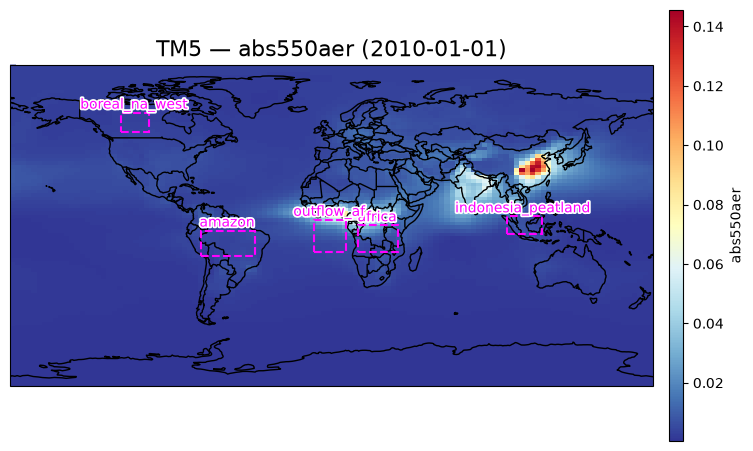

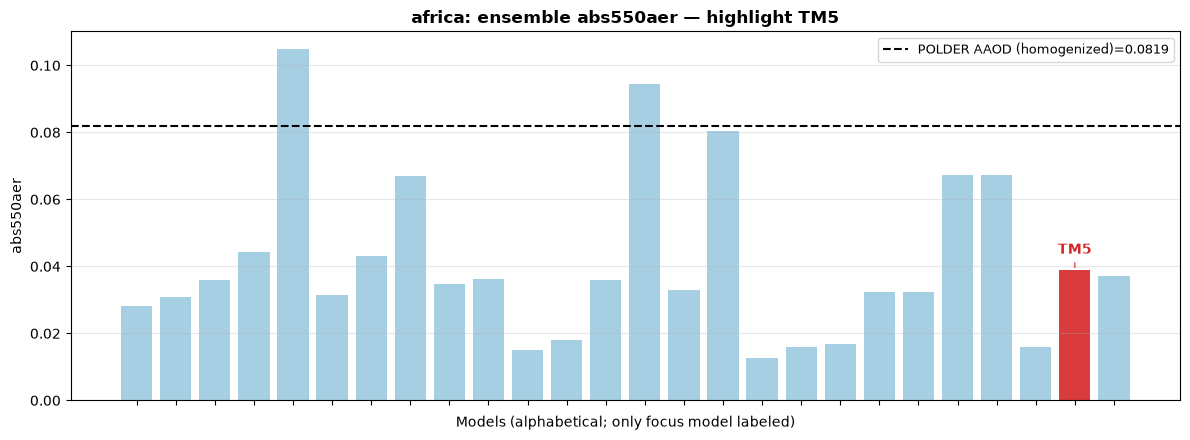


Precipitation (TM5-met2010_AP3-CTRL2019) vs GPCP [mm/day]:
            region  model_precip   GPCP   bias
            africa         1.070  1.105 -0.035
            amazon         2.896  1.896  1.000
        outflow_af         0.770  0.354  0.416
    boreal_na_west         2.505  2.170  0.335
indonesia_peatland         8.583 10.694 -2.111


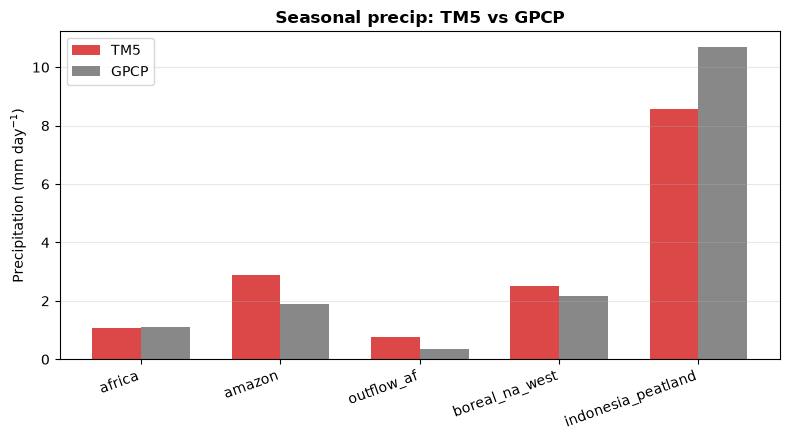


=== Summary (global lifetime) ===
                   model  tau_days     load  sink sink_label
TM5-met2010_AP3-CTRL2019       NaN 0.000006   NaN  emi_BC_OA

Wrote all-model global lifetime table: /scistor/guest/gbb083/AeroCom/notebooks/test_models_global_lifetime.csv


In [21]:
# Run for one model or all models
results = []
for m in focus_models:
    gl = run_model_sanity_check(m)
    results.append({'model': m, **gl})

results_df = pd.DataFrame(results)
print('\n=== Summary (global lifetime) ===')
print(results_df.to_string(index=False))

out_csv = project_root / 'notebooks' / 'test_models_global_lifetime.csv'
# Always refresh the global table for all models; focus results above
global_lifetime_df.to_csv(out_csv, index=False)
print(f'\nWrote all-model global lifetime table: {out_csv}')
if SAVE_FIGURE:
    print(f'Figures directory: {FIG_DIR}')


**Figure / output notes**

- **Global lifetime** uses area-weighted spatial means of load and sink, then one ratio (not the spatial mean of gridcell lifetimes).
- **Regional lifetime** matches `AAOD_error_attribution`: after regional aggregation, `τ = load_BC_OA / (emi_BC_OA · 86400)`.
- **Map** shows `MAP_VAR` for the focus model with study-region boxes.
- **Ensemble plot** shows all models’ seasonal regional `MAP_VAR` in `ENSEMBLE_REGION`; only the focus model is labeled; dashed line is homogenized POLDER when `MAP_VAR` is AAOD or SSA.
- **Precip** compares seasonal regional model precipitation to GPCP for every study region.
